# Implementação didática de GloVe em PyTorch

Este notebook apresenta uma implementação **didática** do modelo **GloVe** em PyTorch, pronta para ser aberta no **Google Colab**.

## Objetivos
- entender a ideia central do GloVe
- construir uma **matriz de coocorrência palavra-palavra**
- implementar a função de custo ponderada do paper
- treinar o modelo em um corpus pequeno
- inspecionar embeddings aprendidos

## Referência
Pennington, Socher e Manning. **GloVe: Global Vectors for Word Representation** (EMNLP 2014).

## O que é o GloVe?

O GloVe pode ser visto como uma ponte entre duas famílias de métodos:

- métodos baseados em **fatoração/global matrix factorization**
- métodos baseados em **janelas locais de contexto**, como o Skip-gram

A ideia central do paper é aprender embeddings a partir de **estatísticas globais de coocorrência** do corpus, em vez de treinar diretamente sobre cada janela de contexto como nos modelos preditivos clássicos.

Em termos intuitivos:

> o modelo tenta ajustar os vetores para que o produto interno entre palavras e contextos recupere o **log da coocorrência** entre elas.

Isso leva a uma função de custo do tipo regressão ponderada.

## Diferença conceitual para o Skip-gram

Embora o GloVe seja frequentemente comparado ao Skip-gram, a pipeline é diferente:

### Skip-gram
- percorre janelas locais
- gera pares `(palavra central, contexto)`
- aprende por predição

### GloVe
- primeiro constrói uma **matriz global de coocorrência**
- depois treina sobre os **elementos não nulos** dessa matriz
- aprende por **regressão log-bilinear ponderada**

Nesta implementação didática, vamos seguir essa segunda ideia.

## Observação importante

Esta versão foi feita para fins pedagógicos. Por isso, usamos:

- corpus pequeno
- vocabulário pequeno
- treinamento simples em PyTorch
- foco em **clareza conceitual**

O paper usa uma configuração muito maior, com corpora enormes, vocabulários muito maiores e escolhas específicas de otimização.

In [1]:
import math
import re
import random
from collections import Counter, defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 1. Corpus didático

Para manter tudo leve e rápido no Colab, usamos um corpus pequeno e repetido várias vezes.

Em um cenário real, o GloVe normalmente é treinado em corpora muito maiores.

In [2]:
base_sentences = [
    "o rei é um homem e a rainha é uma mulher",
    "o príncipe é um homem e a princesa é uma mulher",
    "o rei governa o reino e a rainha governa o palácio",
    "o príncipe vive no palácio e a princesa vive no castelo",
    "o gato é um animal doméstico e o cachorro é um animal doméstico",
    "o gato gosta de leite e o cachorro gosta de osso",
    "python é uma linguagem de programação",
    "pytorch é uma biblioteca para deep learning em python",
    "redes neurais aprendem padrões em dados",
    "aprendizado de máquina usa dados e modelos",
    "programação exige prática e estudo",
    "o carro é um veículo e o ônibus é um veículo",
    "o caminhão é um veículo grande",
    "são paulo fica no brasil",
    "uberlândia fica em minas gerais",
    "o brasil fica na américa do sul",
]

repeat_factor = 120
corpus = " ".join(base_sentences * repeat_factor)

print("Número de frases-base:", len(base_sentences))
print("Repeat factor:", repeat_factor)
print("Tamanho bruto do corpus (caracteres):", len(corpus))
print()
print(corpus[:500] + " ...")

Número de frases-base: 16
Repeat factor: 120
Tamanho bruto do corpus (caracteres): 82079

o rei é um homem e a rainha é uma mulher o príncipe é um homem e a princesa é uma mulher o rei governa o reino e a rainha governa o palácio o príncipe vive no palácio e a princesa vive no castelo o gato é um animal doméstico e o cachorro é um animal doméstico o gato gosta de leite e o cachorro gosta de osso python é uma linguagem de programação pytorch é uma biblioteca para deep learning em python redes neurais aprendem padrões em dados aprendizado de máquina usa dados e modelos programação exig ...


## 2. Tokenização e vocabulário

In [3]:
def tokenize(text: str):
    return re.findall(r"\b[\wà-úãõâêîôûç]+\b", text.lower())

tokens = tokenize(corpus)

special_tokens = ["<PAD>", "<UNK>"]
counter = Counter(tokens)
vocab = special_tokens + sorted(counter.keys())

stoi = {word: idx for idx, word in enumerate(vocab)}
itos = {idx: word for word, idx in stoi.items()}

def encode(word: str) -> int:
    return stoi.get(word, stoi["<UNK>"])

def decode(idx: int) -> str:
    return itos[idx]

print("Número total de tokens:", len(tokens))
print("Tamanho do vocabulário:", len(vocab))
print("Exemplo de tokens:", tokens[:20])

Número total de tokens: 16200
Tamanho do vocabulário: 65
Exemplo de tokens: ['o', 'rei', 'é', 'um', 'homem', 'e', 'a', 'rainha', 'é', 'uma', 'mulher', 'o', 'príncipe', 'é', 'um', 'homem', 'e', 'a', 'princesa', 'é']


## 3. Construindo a matriz de coocorrência

No GloVe, o objeto central não é uma lista de pares individuais como no Skip-gram, mas sim uma **matriz de coocorrência** `X`.

Se uma palavra `j` aparece perto de uma palavra `i`, incrementamos `X[i, j]`.

O paper usa uma ponderação por distância: se duas palavras estão a `d` posições de distância, sua contribuição é `1/d`.

Vamos seguir essa mesma ideia aqui.

In [4]:
window_size = 2

cooccurrence = defaultdict(float)

for center_pos, center_word in enumerate(tokens):
    center_id = encode(center_word)

    left = max(0, center_pos - window_size)
    right = min(len(tokens), center_pos + window_size + 1)

    for context_pos in range(left, right):
        if context_pos == center_pos:
            continue

        context_word = tokens[context_pos]
        context_id = encode(context_word)

        distance = abs(center_pos - context_pos)
        increment = 1.0 / distance

        cooccurrence[(center_id, context_id)] += increment

print("Número de pares não nulos na matriz de coocorrência:", len(cooccurrence))

# Mostrar alguns exemplos
items = list(cooccurrence.items())[:10]
for (i, j), value in items:
    print(f"({decode(i):>10s}, {decode(j):>10s}) -> {value:.2f}")

Número de pares não nulos na matriz de coocorrência: 417
(         o,        rei) -> 300.00
(         o,          é) -> 420.00
(       rei,          o) -> 300.00
(       rei,          é) -> 120.00
(       rei,         um) -> 60.00
(         é,          o) -> 420.00
(         é,        rei) -> 120.00
(         é,         um) -> 840.00
(         é,      homem) -> 120.00
(        um,        rei) -> 60.00


## 4. Transformando a matriz em exemplos de treino

O paper treina sobre os **elementos não nulos** da matriz de coocorrência.  
Cada exemplo terá:

- índice da palavra `i`
- índice da palavra de contexto `j`
- valor de coocorrência `X_ij`

Depois aplicaremos a função de ponderação `f(x)`.

In [5]:
data = []
for (i, j), x_ij in cooccurrence.items():
    data.append((i, j, x_ij))

print("Quantidade total de exemplos de treino:", len(data))
print("Primeiros 5 exemplos:")
for row in data[:5]:
    i, j, x_ij = row
    print(decode(i), "->", decode(j), "| X_ij =", round(x_ij, 4))

Quantidade total de exemplos de treino: 417
Primeiros 5 exemplos:
o -> rei | X_ij = 300.0
o -> é | X_ij = 420.0
rei -> o | X_ij = 300.0
rei -> é | X_ij = 120.0
rei -> um | X_ij = 60.0


## 5. Dataset e DataLoader

In [6]:
class GloVeDataset(Dataset):
    def __init__(self, data):
        self.word_ids = torch.tensor([x[0] for x in data], dtype=torch.long)
        self.context_ids = torch.tensor([x[1] for x in data], dtype=torch.long)
        self.counts = torch.tensor([x[2] for x in data], dtype=torch.float32)

    def __len__(self):
        return len(self.counts)

    def __getitem__(self, idx):
        return self.word_ids[idx], self.context_ids[idx], self.counts[idx]

dataset = GloVeDataset(data)
batch_size = 256
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

sample_w, sample_c, sample_x = next(iter(dataloader))
print("Shape palavras:", sample_w.shape)
print("Shape contextos:", sample_c.shape)
print("Shape contagens:", sample_x.shape)

Shape palavras: torch.Size([256])
Shape contextos: torch.Size([256])
Shape contagens: torch.Size([256])


## 6. A função de ponderação do paper

O GloVe usa a seguinte função de ponderação:

\[
f(x) =
\begin{cases}
(x / x_{max})^{\alpha}, & x < x_{max} \\
1, & \text{caso contrário}
\end{cases}
\]

A intuição é:

- **coocorrências muito raras** são ruidosas
- **coocorrências mutio frequentes** não devem dominar excessivamente
- a ponderação equilibra esses dois extremos

O paper usa tipicamente:

- `x_max = 100`
- `alpha = 3/4`

In [7]:
def glove_weighting_function(x, x_max=100.0, alpha=0.75):
    x = torch.as_tensor(x, dtype=torch.float32)
    return torch.where(x < x_max, (x / x_max) ** alpha, torch.ones_like(x))

test_x = torch.tensor([0.1, 1.0, 5.0, 20.0, 100.0, 500.0])
test_f = glove_weighting_function(test_x)

for a, b in zip(test_x.tolist(), test_f.tolist()):
    print(f"x = {a:>6.1f} -> f(x) = {b:.4f}")

x =    0.1 -> f(x) = 0.0056
x =    1.0 -> f(x) = 0.0316
x =    5.0 -> f(x) = 0.1057
x =   20.0 -> f(x) = 0.2991
x =  100.0 -> f(x) = 1.0000
x =  500.0 -> f(x) = 1.0000


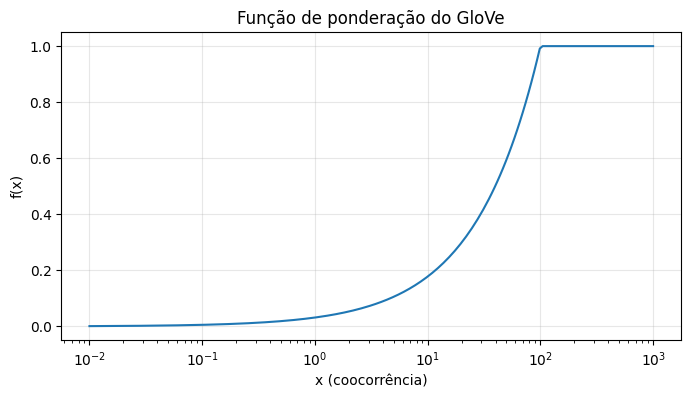

In [8]:
xs = torch.logspace(-2, 3, steps=200)
ys = glove_weighting_function(xs)

plt.figure(figsize=(8, 4))
plt.plot(xs.numpy(), ys.numpy())
plt.xscale("log")
plt.xlabel("x (coocorrência)")
plt.ylabel("f(x)")
plt.title("Função de ponderação do GloVe")
plt.grid(True, alpha=0.3)
plt.show()

## 7. Implementando o modelo GloVe em PyTorch

O paper propõe ajustar a seguinte quantidade:

\[
w_i^T \tilde{w}_j + b_i + \tilde{b}_j \approx \log(X_{ij})
\]

Portanto, o modelo precisa de:

- embeddings para palavras `W`
- embeddings para contextos `\tilde{W}`
- bias para palavras
- bias para contextos

E a loss ponderada é:

\[
J = \sum_{i,j} f(X_{ij}) \left(w_i^T \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij}\right)^2
\]

In [9]:
class GloVeModel(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int):
        super().__init__()
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.context_embeddings = nn.Embedding(vocab_size, embedding_dim)

        self.word_biases = nn.Embedding(vocab_size, 1)
        self.context_biases = nn.Embedding(vocab_size, 1)

        # Inicialização pequena ajuda na estabilidade
        nn.init.xavier_uniform_(self.word_embeddings.weight)
        nn.init.xavier_uniform_(self.context_embeddings.weight)
        nn.init.zeros_(self.word_biases.weight)
        nn.init.zeros_(self.context_biases.weight)

    def forward(self, word_ids, context_ids):
        w = self.word_embeddings(word_ids)          # [B, D]
        c = self.context_embeddings(context_ids)    # [B, D]

        b_w = self.word_biases(word_ids).squeeze(-1)       # [B]
        b_c = self.context_biases(context_ids).squeeze(-1) # [B]

        dot = torch.sum(w * c, dim=1)               # [B]
        return dot + b_w + b_c

vocab_size = len(vocab)
embedding_dim = 32

model = GloVeModel(vocab_size=vocab_size, embedding_dim=embedding_dim).to(device)
print(model)

GloVeModel(
  (word_embeddings): Embedding(65, 32)
  (context_embeddings): Embedding(65, 32)
  (word_biases): Embedding(65, 1)
  (context_biases): Embedding(65, 1)
)


## 8. Definindo a loss do GloVe

A loss é um erro quadrático ponderado entre:

- a predição do modelo
- `log(X_ij)`

Como treinamos apenas com pares não nulos, `X_ij > 0`, então `log(X_ij)` é bem definido.

In [10]:
def glove_loss(predictions, counts, x_max=100.0, alpha=0.75):
    weights = glove_weighting_function(counts, x_max=x_max, alpha=alpha).to(predictions.device)
    log_counts = torch.log(counts).to(predictions.device)
    return torch.mean(weights * (predictions - log_counts) ** 2)

## 9. Treinamento

O paper usa **AdaGrad**, então vamos seguir essa mesma escolha.

Como o corpus aqui é pequeno, poucas épocas já são suficientes para observar a queda da loss.

In [11]:
learning_rate = 0.05
epochs = 30
x_max = 100.0
alpha = 0.75

optimizer = torch.optim.Adagrad(model.parameters(), lr=learning_rate)

history = []

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0

    for batch_word, batch_context, batch_count in dataloader:
        batch_word = batch_word.to(device)
        batch_context = batch_context.to(device)
        batch_count = batch_count.to(device)

        optimizer.zero_grad()

        preds = model(batch_word, batch_context)
        loss = glove_loss(preds, batch_count, x_max=x_max, alpha=alpha)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)
    history.append(epoch_loss)

    if epoch == 1 or epoch % 5 == 0:
        print(f"Época {epoch:02d} | loss médio = {epoch_loss:.4f}")

Época 01 | loss médio = 18.5970
Época 05 | loss médio = 9.9996
Época 10 | loss médio = 2.7901
Época 15 | loss médio = 0.5698
Época 20 | loss médio = 0.1949
Época 25 | loss médio = 0.1120
Época 30 | loss médio = 0.0782


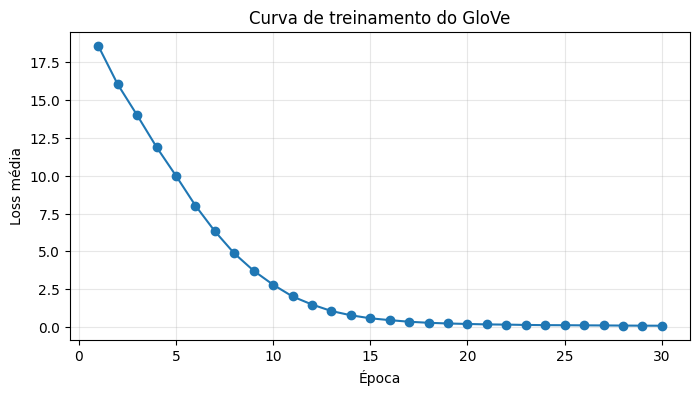

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history) + 1), history, marker="o")
plt.xlabel("Época")
plt.ylabel("Loss média")
plt.title("Curva de treinamento do GloVe")
plt.grid(True, alpha=0.3)
plt.show()

## 10. Obtendo os embeddings finais

O paper comenta que o modelo aprende dois conjuntos de vetores:

- `W`
- `\tilde{W}`

Em prática, é comum usar:

\[
W + \tilde{W}
\]

como embedding final de cada palavra.

Vamos fazer isso aqui.

In [13]:
@torch.no_grad()
def get_final_embeddings(model):
    word_vecs = model.word_embeddings.weight.detach().cpu()
    context_vecs = model.context_embeddings.weight.detach().cpu()
    return word_vecs + context_vecs

final_embeddings = get_final_embeddings(model)
print("Shape dos embeddings finais:", final_embeddings.shape)

Shape dos embeddings finais: torch.Size([65, 32])


## 11. Vizinhos mais próximos

Vamos usar similaridade do cosseno para inspecionar quais palavras ficaram próximas no espaço vetorial.

In [14]:
@torch.no_grad()
def nearest_neighbors(embeddings, word, topk=5):
    if word not in stoi:
        raise ValueError(f"Palavra '{word}' não está no vocabulário.")

    emb = embeddings / embeddings.norm(dim=1, keepdim=True).clamp_min(1e-12)
    idx = stoi[word]
    query = emb[idx]
    sims = emb @ query

    values, indices = torch.topk(sims, k=topk + 1)

    neighbors = []
    for sim, j in zip(values.tolist(), indices.tolist()):
        token = decode(j)
        if token == word:
            continue
        neighbors.append((token, sim))
        if len(neighbors) == topk:
            break
    return neighbors

for word in ["rei", "rainha", "python", "gato", "veículo", "brasil"]:
    print(f"Vizinhos de '{word}':")
    for neighbor, sim in nearest_neighbors(final_embeddings, word, topk=5):
        print(f"  {neighbor:12s} -> {sim:.4f}")
    print()

Vizinhos de 'rei':
  mulher       -> 0.9082
  o            -> 0.8883
  governa      -> 0.8773
  carro        -> 0.8646
  ônibus       -> 0.7924

Vizinhos de 'rainha':
  a            -> 0.9156
  governa      -> 0.8750
  gosta        -> 0.8666
  leite        -> 0.8393
  homem        -> 0.8375

Vizinhos de 'python':
  redes        -> 0.8991
  osso         -> 0.8675
  neurais      -> 0.8460
  é            -> 0.8265
  em           -> 0.8179

Vizinhos de 'gato':
  gosta        -> 0.8897
  o            -> 0.8737
  castelo      -> 0.8685
  ônibus       -> 0.8648
  doméstico    -> 0.8524

Vizinhos de 'veículo':
  um           -> 0.9046
  caminhão     -> 0.8887
  o            -> 0.8690
  ônibus       -> 0.8608
  grande       -> 0.8606

Vizinhos de 'brasil':
  uberlândia   -> 0.9378
  fica         -> 0.9376
  no           -> 0.7847
  gerais       -> 0.7448
  na           -> 0.7063



## 12. Inspecionando aproximações de coocorrência

Como o GloVe tenta ajustar:

\[
w_i^T \tilde{w}_j + b_i + \tilde{b}_j \approx \log(X_{ij})
\]

podemos comparar:

- valor previsto pelo modelo
- valor real `log(X_ij)`

In [15]:
@torch.no_grad()
def inspect_pair(model, word_a, word_b):
    i = torch.tensor([stoi[word_a]], dtype=torch.long, device=device)
    j = torch.tensor([stoi[word_b]], dtype=torch.long, device=device)

    pred = model(i, j).item()
    x_ij = cooccurrence.get((stoi[word_a], stoi[word_b]), 0.0)
    log_x = math.log(x_ij) if x_ij > 0 else None

    return {
        "word": word_a,
        "context": word_b,
        "X_ij": x_ij,
        "log_X_ij": log_x,
        "prediction": pred,
    }

pairs_to_check = [
    ("rei", "rainha"),
    ("rei", "homem"),
    ("python", "programação"),
    ("gato", "animal"),
    ("brasil", "américa"),
]

for wa, wb in pairs_to_check:
    result = inspect_pair(model, wa, wb)
    print(result)

{'word': 'rei', 'context': 'rainha', 'X_ij': 0.0, 'log_X_ij': None, 'prediction': 2.728652238845825}
{'word': 'rei', 'context': 'homem', 'X_ij': 0.0, 'log_X_ij': None, 'prediction': 2.3509044647216797}
{'word': 'python', 'context': 'programação', 'X_ij': 0.0, 'log_X_ij': None, 'prediction': 3.225301504135132}
{'word': 'gato', 'context': 'animal', 'X_ij': 0.0, 'log_X_ij': None, 'prediction': 3.152444839477539}
{'word': 'brasil', 'context': 'américa', 'X_ij': 0.0, 'log_X_ij': None, 'prediction': 3.4204328060150146}


## 13. Visualização 2D dos embeddings

Vamos projetar alguns embeddings em 2 dimensões usando PCA.

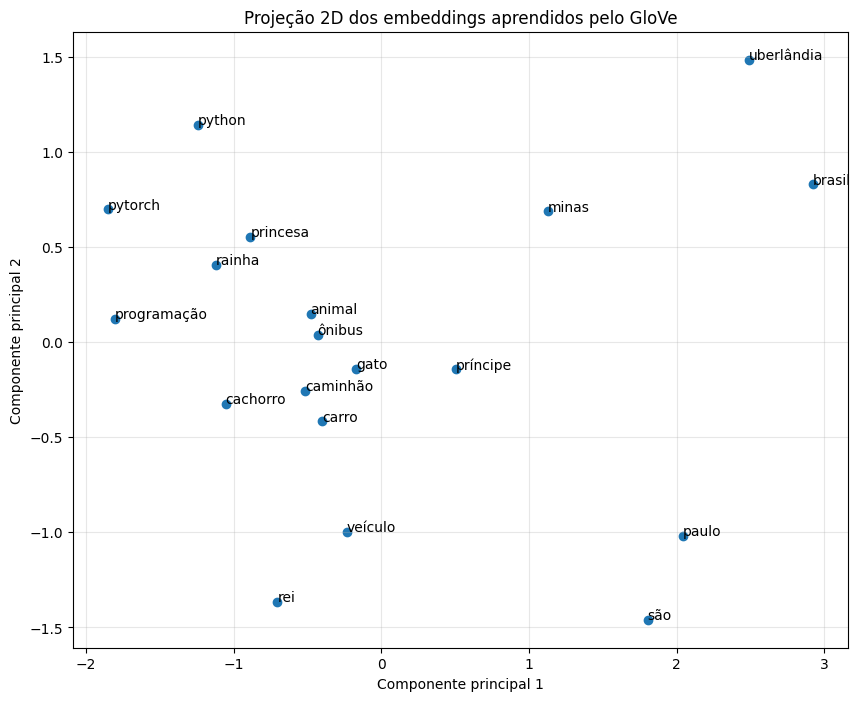

In [16]:
selected_words = [
    "rei", "rainha", "príncipe", "princesa",
    "gato", "cachorro", "animal",
    "python", "pytorch", "programação",
    "carro", "ônibus", "caminhão", "veículo",
    "brasil", "são", "paulo", "uberlândia", "minas",
]

selected_words = [w for w in selected_words if w in stoi]
selected_ids = torch.tensor([stoi[w] for w in selected_words], dtype=torch.long)

E = final_embeddings[selected_ids]
E = E - E.mean(dim=0, keepdim=True)
U, S, V = torch.pca_lowrank(E, q=2)
coords = E @ V[:, :2]

plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1])

for i, word in enumerate(selected_words):
    plt.annotate(word, (coords[i, 0].item(), coords[i, 1].item()))

plt.title("Projeção 2D dos embeddings aprendidos pelo GloVe")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True, alpha=0.3)
plt.show()

## 14. Relação entre GloVe, CBOW e Skip-gram

Vale comparar as três ideias:

### CBOW
- contexto -> palavra central
- objetivo de predição simples

### Skip-gram
- palavra central -> contexto
- também é um modelo preditivo

### GloVe
- usa **contagens globais de coocorrência**
- ajusta vetores para aproximar `log(X_ij)`
- usa uma **loss de regressão ponderada**
- treina apenas sobre os **elementos não nulos** da matriz de coocorrência

Essa é a principal mudança de pipeline.

## 15. Como aproximar mais esta implementação do paper

Para tornar esta versão mais fiel ao artigo, podemos:

1. usar um corpus real grande
2. aumentar o vocabulário
3. usar janela de contexto maior
4. manter ponderação por distância `1/d`
5. treinar por mais épocas
6. usar dimensões maiores
7. salvar os embeddings finais em arquivo

O paper reporta resultados fortes em analogias, similaridade e NER usando corpora muito maiores.

In [ ]:
# Exemplo opcional para usar um texto próprio no Google Colab:
#
# try:
#     from google.colab import files
#     uploaded = files.upload()
#     filename = next(iter(uploaded))
#     with open(filename, "r", encoding="utf-8") as f:
#         corpus = f.read()
#     print("Novo corpus carregado com sucesso.")
# except Exception as e:
#     print("Este bloco é opcional e foi pensado para o Google Colab.")
#     print("Detalhe:", e)

## 16. Resumo

Nesta implementação, o fluxo do GloVe ficou assim:

**corpus -> matriz de coocorrência -> pares não nulos -> regressão ponderada sobre log(X_ij) -> embeddings**

Esse é o ponto central do método:

- usar estatísticas globais do corpus
- modelar o log da coocorrência
- aprender vetores densos com estrutura semântica útil

Este notebook forma um trio natural com as implementações didáticas de **CBOW** e **Skip-gram**.